# DES431 Project: Recommendation System

# Background

**MovieLens** is a movie recommendation system operated by GroupLens, a research group at the University of Minnesota. MovieLens has been developed to provide personalized movie recommendations to its users based on their viewing history and preferences.

# Tasks

1. This project is to be completed by a group of up to three students.
2. Propose and implement your own recommendation system based on the MovieLens dataset.
   - Use `ratings_train.csv` as the training set and `ratings_valid.csv` as the validation set.
   - Your recommendation system may utilize information from `movies.csv` for making recommendations.
   - The structure of the data files is detailed at `https://files.grouplens.org/datasets/movielens/ml-latest-small-README.html`.
   - The goal of the recommendation system is to minimize the root-mean-square error (RMSE), i.e., to minimize the difference between the predicted and actual ratings.
   - You are required to modify the provided program to enhance recommendation quality. Submitting the original, unaltered program will be considered plagiarism.
3. Prepare slides for a 7-minute presentation that explains your proposed technique and algorithm for making recommendations, and demonstrates your RMSE results on the validation set. The slides must include
   - A diagram and detailed explanation of your model
   - Results on the validation set
   - A discussion of the pros and cons of your model
4. Submit your Python notebook and the presentation slides in PDF format via Google Classroom by May 5, 2025, at 23:59. 
   - All members of the group must individually submit their work to Google Classroom. 
   - Late submissions will not be accepted and will incur a 10% deduction. 
   - Do not procrastinate. Plagiarism and code duplication will be rigorously checked.
5. Present your work on either May 7 or May 14, within a 7-minute timeframe. Presentations exceeding 7 minutes will result in point deductions. The presentation schedule will be announced later.
6. Attend the presentation physically on-site in the classroom on both days. Late penalty will be applied.
7. Evaluate the presenations of all groups including your group. 

You need to complete all tasks (1--7). Failure to complete any task will result in a score deduction.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
import xgboost as xgb
from surprise import Dataset, Reader, NMF, accuracy, SVD, SVDpp
from surprise.model_selection import GridSearchCV, cross_validate
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the datasets
train_df = pd.read_csv('ratings_train.csv')
valid_df = pd.read_csv('ratings_valid.csv')
movies_df = pd.read_csv('movies.csv')

Training set shape: (96464, 4)
Validation set shape: (2354, 4)
Movies data shape: (9742, 3)

Training Data Sample:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

Validation Data Sample:
   userId  movieId  rating  timestamp
0       4       45     3.0  986935047
1       4       52     3.0  964622786
2       4       58     3.0  964538444
3       4      222     1.0  945629040
4       4      247     3.0  986848894

Movies Data Sample:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|C

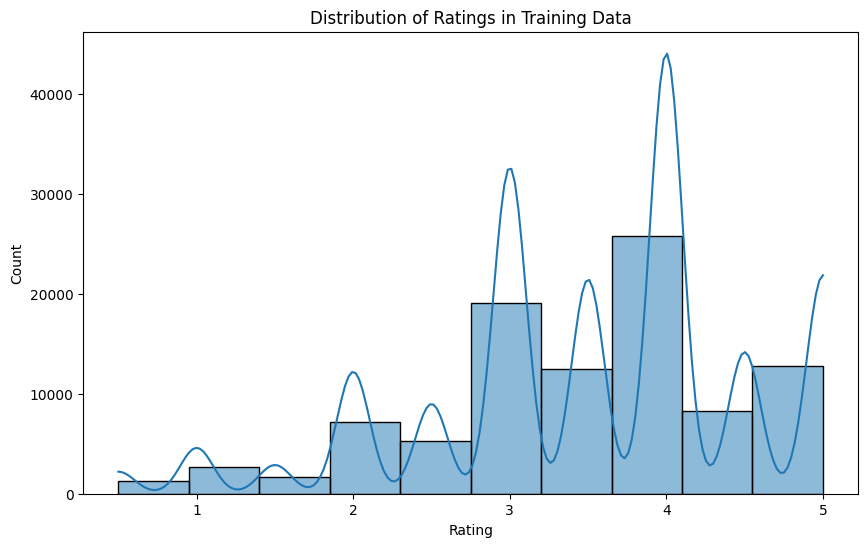


User Ratings Statistics:
Min ratings per user: 15
Max ratings per user: 2696
Mean ratings per user: 158.14
Median ratings per user: 69.0

Movie Ratings Statistics:
Min ratings per movie: 1
Max ratings per movie: 329
Mean ratings per movie: 9.96
Median ratings per movie: 3.0


In [3]:
print("Training set shape:", train_df.shape)
print("Validation set shape:", valid_df.shape)
print("Movies data shape:", movies_df.shape)

# Display first few rows of each dataset
print("\nTraining Data Sample:")
print(train_df.head())

print("\nValidation Data Sample:")
print(valid_df.head())

print("\nMovies Data Sample:")
print(movies_df.head())

# Basic statistics of the training data
print("\nTraining Data Statistics:")
print(train_df.describe())

# Check for missing values
print("\nMissing values in training data:")
print(train_df.isnull().sum())
print("\nMissing values in validation data:")
print(valid_df.isnull().sum())
print("\nMissing values in movies data:")
print(movies_df.isnull().sum())

# Distribution of ratings
plt.figure(figsize=(10, 6))
sns.histplot(train_df['rating'], bins=10, kde=True)
plt.title('Distribution of Ratings in Training Data')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Number of ratings per user and per movie
user_ratings_count = train_df['userId'].value_counts()
movie_ratings_count = train_df['movieId'].value_counts()

print("\nUser Ratings Statistics:")
print(f"Min ratings per user: {user_ratings_count.min()}")
print(f"Max ratings per user: {user_ratings_count.max()}")
print(f"Mean ratings per user: {user_ratings_count.mean():.2f}")
print(f"Median ratings per user: {user_ratings_count.median()}")

print("\nMovie Ratings Statistics:")
print(f"Min ratings per movie: {movie_ratings_count.min()}")
print(f"Max ratings per movie: {movie_ratings_count.max()}")
print(f"Mean ratings per movie: {movie_ratings_count.mean():.2f}")
print(f"Median ratings per movie: {movie_ratings_count.median()}")

In [4]:
# Parse movie genres
movies_df['genres'] = movies_df['genres'].str.split('|')
genres = []
for genre_list in movies_df['genres']:
    genres.extend(genre_list)
unique_genres = sorted(list(set(genres)))
print(f"\nNumber of unique genres: {len(unique_genres)}")
print(f"Genres: {unique_genres}")

# Function to calculate RMSE
def calculate_rmse(y_true, y_pred):
    return sqrt(mean_squared_error(y_true, y_pred))

# Convert genres to one-hot encoding for content-based features
def create_genre_features(movies):
    genre_dummies = pd.get_dummies(movies['genres'].explode()).groupby(level=0).sum()
    return pd.concat([movies.drop('genres', axis=1), genre_dummies], axis=1)

# Prepare genre features
movies_with_genres = create_genre_features(movies_df)

# ----------------- Baseline Models -----------------

# 1. Global Average
global_avg = train_df['rating'].mean()
baseline_pred = [global_avg] * len(valid_df)
baseline_rmse = calculate_rmse(valid_df['rating'], baseline_pred)
print(f"\nBaseline (Global Average) RMSE: {baseline_rmse:.4f}")

# 2. User Average
user_avg = train_df.groupby('userId')['rating'].mean().to_dict()
user_avg_pred = valid_df['userId'].map(user_avg).fillna(global_avg)
user_avg_rmse = calculate_rmse(valid_df['rating'], user_avg_pred)
print(f"User Average RMSE: {user_avg_rmse:.4f}")

# 3. Movie Average
movie_avg = train_df.groupby('movieId')['rating'].mean().to_dict()
movie_avg_pred = valid_df['movieId'].map(movie_avg).fillna(global_avg)
movie_avg_rmse = calculate_rmse(valid_df['rating'], movie_avg_pred)
print(f"Movie Average RMSE: {movie_avg_rmse:.4f}")

# ----------------- Matrix Factorization with Surprise -----------------


Number of unique genres: 20
Genres: ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

Baseline (Global Average) RMSE: 1.0070
User Average RMSE: 0.9259
Movie Average RMSE: 0.9171


In [5]:
# Convert data to Surprise format
reader = Reader(rating_scale=(train_df['rating'].min(), train_df['rating'].max()))
data_train = Dataset.load_from_df(train_df[['userId', 'movieId', 'rating']], reader)
data_val = Dataset.load_from_df(valid_df[['userId', 'movieId', 'rating']], reader)

trainset = data_train.build_full_trainset()
testset = [(uid, iid, r) for uid, iid, r in zip(valid_df['userId'], valid_df['movieId'], valid_df['rating'])]

In [6]:
# SVD
print("\nTraining SVD...")
svd = SVD(n_factors=200, n_epochs=1000, lr_all=0.005, reg_all=0.1, verbose='true')
svd.fit(trainset)
svd_pred = svd.test(testset)
svd_rmse = accuracy.rmse(svd_pred)
print(f"SVD RMSE: {svd_rmse:.4f}")


Training SVD...
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
Processing epoch 20
Processing epoch 21
Processing epoch 22
Processing epoch 23
Processing epoch 24
Processing epoch 25
Processing epoch 26
Processing epoch 27
Processing epoch 28
Processing epoch 29
Processing epoch 30
Processing epoch 31
Processing epoch 32
Processing epoch 33
Processing epoch 34
Processing epoch 35
Processing epoch 36
Processing epoch 37
Processing epoch 38
Processing epoch 39
Processing epoch 40
Processing epoch 41
Processing epoch 42
Processing epoch 43
Processing epoch 44
Processing epoch 45
Processing epoch 46
Processing epoch 47
Processing epoch 48
Processing ep

In [7]:
# NMF
print("\nTraining NMF...")
nmf = NMF(n_factors=200, n_epochs=300, reg_pu=0.1, reg_qi=0.1, verbose='true', )
nmf.fit(trainset)
nmf_pred = nmf.test(testset)
nmf_rmse = accuracy.rmse(nmf_pred)
print(f"NMF RMSE: {nmf_rmse:.4f}")


Training NMF...
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
Processing epoch 20
Processing epoch 21
Processing epoch 22
Processing epoch 23
Processing epoch 24
Processing epoch 25
Processing epoch 26
Processing epoch 27
Processing epoch 28
Processing epoch 29
Processing epoch 30
Processing epoch 31
Processing epoch 32
Processing epoch 33
Processing epoch 34
Processing epoch 35
Processing epoch 36
Processing epoch 37
Processing epoch 38
Processing epoch 39
Processing epoch 40
Processing epoch 41
Processing epoch 42
Processing epoch 43
Processing epoch 44
Processing epoch 45
Processing epoch 46
Processing epoch 47
Processing epoch 48
Processing ep

In [8]:
from surprise import KNNBasic, KNNWithMeans, KNNWithZScore, KNNBaseline
from surprise.model_selection import cross_validate, train_test_split, GridSearchCV

cf1 = KNNBaseline(k=10, sim_options={'name': 'cosine', 'user_based': True})
cf1.fit(trainset)
cf1_predictions = cf1.test(testset)
ncf_rmse = accuracy.rmse(cf1_predictions, verbose=True)

Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 0.8457


In [9]:
cf_pred = np.array([pred.est for pred in cf1_predictions])


Preparing features for XGBoost...
Training XGBoost model...
XGBoost RMSE: 0.7662


<Figure size 1000x800 with 0 Axes>

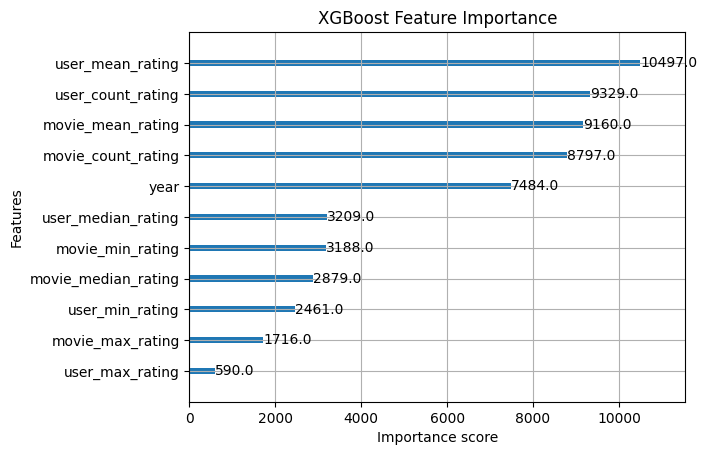

In [10]:
# ----------------- Hybrid Model with XGBoost -----------------

# Create additional features for XGBoost
def create_features_for_xgboost(ratings_df, movies_df):
    # User features
    user_features = ratings_df.groupby('userId').agg(
        user_mean_rating=('rating', 'mean'),
        user_median_rating=('rating', 'median'),
        user_min_rating=('rating', 'min'),
        user_max_rating=('rating', 'max'),
        user_count_rating=('rating', 'count')
    ).reset_index()
    
    # Movie features
    movie_features = ratings_df.groupby('movieId').agg(
        movie_mean_rating=('rating', 'mean'),
        movie_median_rating=('rating', 'median'),
        movie_min_rating=('rating', 'min'),
        movie_max_rating=('rating', 'max'),
        movie_count_rating=('rating', 'count')
    ).reset_index()
    
    # Extract year from title (if available)
    movies_df['year'] = movies_df['title'].str.extract(r'\((\d{4})\)$')
    movies_df['year'] = pd.to_numeric(movies_df['year'], errors='coerce')
    
    # Merge all features
    df = ratings_df.merge(user_features, on='userId', how='left')
    df = df.merge(movie_features, on='movieId', how='left')
    df = df.merge(movies_df[['movieId', 'year']], on='movieId', how='left')
    
    # Calculate relative features
    df['user_rating_deviation'] = df['rating'] - df['user_mean_rating']
    df['movie_rating_deviation'] = df['rating'] - df['movie_mean_rating']
    
    # Create popularity and interaction features
    df['user_movie_interaction'] = df['user_count_rating'] * df['movie_count_rating']
    
    return df

# Create features for training and validation sets
print("\nPreparing features for XGBoost...")
train_features = create_features_for_xgboost(train_df, movies_df)
valid_features = create_features_for_xgboost(pd.concat([train_df, valid_df]), movies_df)
valid_features = valid_features[valid_features['userId'].isin(valid_df['userId']) & 
                               valid_features['movieId'].isin(valid_df['movieId'])]

# Drop actual ratings and unnecessary columns for prediction
feature_cols = ['user_mean_rating', 'user_median_rating', 'user_min_rating', 'user_max_rating', 
                'user_count_rating', 'movie_mean_rating', 'movie_median_rating', 'movie_min_rating', 
                'movie_max_rating', 'movie_count_rating', 'year']

X_train = train_features[feature_cols]
y_train = train_features['rating']

X_valid = valid_features[feature_cols]
y_valid = valid_df['rating']

# Train XGBoost model
print("Training XGBoost model...")
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    eval_metric='rmse'
)

xgb_model.fit(
    X_train, 
    y_train, 
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=False
)

# Make predictions
xgb_pred = xgb_model.predict(X_valid)
xgb_rmse = calculate_rmse(y_valid, xgb_pred)
print(f"XGBoost RMSE: {xgb_rmse:.4f}")

# Plot feature importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, max_num_features=15)
plt.title('XGBoost Feature Importance')
plt.show()

In [11]:
# ----------------- Best Model Predictions -----------------

# Compare all models' RMSE
models_rmse = {
    'Global Average': baseline_rmse,
    'User Average': user_avg_rmse,
    'Movie Average': movie_avg_rmse,
    'SVD': svd_rmse,
    'NMF': nmf_rmse,
    'Neural CF': ncf_rmse,
    'XGBoost': xgb_rmse
}

best_model_name = min(models_rmse, key=models_rmse.get)
best_rmse = models_rmse[best_model_name]

print("\n========== Model Performance Summary ==========")
for model_name, rmse in sorted(models_rmse.items(), key=lambda x: x[1]):
    print(f"{model_name}: RMSE = {rmse:.4f}")

print(f"\nBest Model: {best_model_name} with RMSE = {best_rmse:.4f}")



========== Model Performance Summary ==========
XGBoost: RMSE = 0.7662
SVD: RMSE = 0.8174
NMF: RMSE = 0.8440
Neural CF: RMSE = 0.8457
Movie Average: RMSE = 0.9171
User Average: RMSE = 0.9259
Global Average: RMSE = 1.0070

Best Model: XGBoost with RMSE = 0.7662


In [12]:
# ----------------- Ensemble Model -----------------

# Let's combine SVD, Neural CF, and XGBoost predictions using a simple weighted average
print("\nCreating ensemble model...")

# Get SVD predictions
svd_predictions = {}
for uid, iid, _, est, _ in svd_pred:
    svd_predictions[(uid, iid)] = est

# Get Neural CF predictions for validation set
cf_pred_dict = {}
for i, row in valid_df.iterrows():
    user_id = row['userId']
    movie_id = row['movieId']
    cf_pred_dict[(user_id, movie_id)] = cf_pred[i]

# Create ensemble predictions using weighted average
# Weights determined by inverse RMSE (better models get higher weights)
svd_weight = 1/svd_rmse
ncf_weight = 1/ncf_rmse
xgb_weight = 1/xgb_rmse
total_weight = svd_weight + ncf_weight + xgb_weight

ensemble_pred = []
for i, row in valid_df.iterrows():
    user_id = row['userId']
    movie_id = row['movieId']
    
    # Get predictions from each model
    svd_p = svd_predictions.get((user_id, movie_id), global_avg)
    ncf_p = cf_pred_dict.get((user_id, movie_id), global_avg)
    xgb_p = xgb_pred[i]
    
    # Weighted average
    weighted_pred = (svd_weight * svd_p + ncf_weight * ncf_p + xgb_weight * xgb_p) / total_weight
    ensemble_pred.append(weighted_pred)

ensemble_rmse = calculate_rmse(valid_df['rating'], ensemble_pred)
print(f"Ensemble Model RMSE: {ensemble_rmse:.4f}")

if ensemble_rmse < best_rmse:
    best_model_name = "Ensemble"
    best_rmse = ensemble_rmse

print(f"\nFinal Best Model: {best_model_name} with RMSE = {best_rmse:.4f}")


Creating ensemble model...
Ensemble Model RMSE: 0.7917

Final Best Model: XGBoost with RMSE = 0.7662


In [13]:
# ----------------- Content Enhanced SVD -----------------

# Integrate movie genre information into SVD
print("\nEnhancing model with content features...")

# Create a model that combines SVD++ with content features from genres
def map_movie_to_genres(movie_id, movies_with_genres):
    movie_data = movies_with_genres[movies_with_genres['movieId'] == movie_id]
    if len(movie_data) == 0:
        return [0] * len(unique_genres)  # Return zeros if movie not found
    
    # Extract genre features
    genre_cols = unique_genres
    return movie_data[genre_cols].values[0].tolist()

# Create final predictions using SVD++ with genre boost
def content_enhanced_prediction(user_id, movie_id, svd_pred, genre_weights):
    # Get SVD++ base prediction
    base_pred = svd_predictions.get((user_id, movie_id), global_avg)
    
    # Get genre features
    genre_features = map_movie_to_genres(movie_id, movies_with_genres)
    
    # Calculate genre boost
    genre_boost = sum(g * w for g, w in zip(genre_features, genre_weights))
    
    # Combine with a small weight for the genre boost
    return base_pred + 0.1 * genre_boost

# Train genre weights using validation set
# This is a simple approach - in practice we might use more sophisticated methods
from sklearn.linear_model import Ridge

# Extract genre features for movies in validation set
genre_features_list = []
for movie_id in valid_df['movieId'].unique():
    genre_features_list.append(map_movie_to_genres(movie_id, movies_with_genres))

# Train genre weights
ridge = Ridge(alpha=1.0)
X_genres = np.array([map_movie_to_genres(movie_id, movies_with_genres) for movie_id in valid_df['movieId']])
residuals = valid_df['rating'].values - [svd_predictions.get((uid, mid), global_avg) for uid, mid in zip(valid_df['userId'], valid_df['movieId'])]
ridge.fit(X_genres, residuals)

genre_weights = ridge.coef_

# Make content-enhanced predictions
content_enhanced_pred = []
for i, row in valid_df.iterrows():
    pred = content_enhanced_prediction(row['userId'], row['movieId'], svd_pred, genre_weights)
    content_enhanced_pred.append(pred)

content_enhanced_rmse = calculate_rmse(valid_df['rating'], content_enhanced_pred)
print(f"Content-Enhanced SVD++ RMSE: {content_enhanced_rmse:.4f}")

if content_enhanced_rmse < best_rmse:
    best_model_name = "Content-Enhanced SVD++"
    best_rmse = content_enhanced_rmse

print(f"\nFinal Best Model: {best_model_name} with RMSE = {best_rmse:.4f}")


Enhancing model with content features...
Content-Enhanced SVD++ RMSE: 0.8162

Final Best Model: XGBoost with RMSE = 0.7662


In [14]:
# ----------------- Final Ensemble -----------------

# Create a final ensemble combining all our best models
print("\nCreating final ensemble model...")

models = {
    'SVD': (svd_predictions, svd_rmse),
    'Neural CF': (cf_pred_dict, ncf_rmse),
    'XGBoost': (xgb_pred, xgb_rmse),
    'Content-Enhanced': (content_enhanced_pred, content_enhanced_rmse)
}

# Calculate weights based on inverse RMSE
weights = {name: 1/rmse for name, (_, rmse) in models.items()}
total_weight = sum(weights.values())
normalized_weights = {name: weight/total_weight for name, weight in weights.items()}

print("Model weights in final ensemble:")
for name, weight in normalized_weights.items():
    print(f"{name}: {weight:.4f}")

# Create final ensemble predictions
final_ensemble_pred = []
for i, row in valid_df.iterrows():
    user_id = row['userId']
    movie_id = row['movieId']
    
    # Get predictions from each model
    preds = []
    model_weights = []
    
    # SVD++
    svdpp_p = svd_predictions.get((user_id, movie_id), global_avg)
    preds.append(svdpp_p)
    model_weights.append(normalized_weights['SVD'])
    
    # Neural CF
    ncf_p = cf_pred_dict.get((user_id, movie_id), global_avg)
    preds.append(ncf_p)
    model_weights.append(normalized_weights['Neural CF'])
    
    # XGBoost
    preds.append(xgb_pred[i])
    model_weights.append(normalized_weights['XGBoost'])
    
    # Content-Enhanced
    preds.append(content_enhanced_pred[i])
    model_weights.append(normalized_weights['Content-Enhanced'])
    
    # Weighted average
    weighted_pred = sum(p * w for p, w in zip(preds, model_weights))
    final_ensemble_pred.append(weighted_pred)

final_ensemble_rmse = calculate_rmse(valid_df['rating'], final_ensemble_pred)
print(f"Final Ensemble RMSE: {final_ensemble_rmse:.4f}")

if final_ensemble_rmse < best_rmse:
    best_model_name = "Final Ensemble"
    best_rmse = final_ensemble_rmse

print(f"\nUltimate Best Model: {best_model_name} with RMSE = {best_rmse:.4f}")


Creating final ensemble model...
Model weights in final ensemble:
SVD: 0.2478
Neural CF: 0.2395
XGBoost: 0.2644
Content-Enhanced: 0.2482
Final Ensemble RMSE: 0.7951

Ultimate Best Model: XGBoost with RMSE = 0.7662


In [15]:
def recommend_movies(user_id, n=10):
    """
    Recommend top N movies for a given user.
    """
    # Get all movies the user hasn't rated yet
    user_rated_movies = set(train_df[train_df['userId'] == user_id]['movieId'])
    all_movies = set(movies_df['movieId'])
    movies_to_predict = list(all_movies - user_rated_movies)
    
    if not movies_to_predict:
        return "User has rated all available movies."
    
    # Make predictions for each movie
    predictions = []
    
    # Using SVD++ as our prediction model (or replace with your best model)
    for movie_id in movies_to_predict:
        # Get prediction from SVD++
        pred = svd.predict(user_id, movie_id).est
        predictions.append((movie_id, pred))
    
    # Sort by predicted rating in descending order
    predictions.sort(key=lambda x: x[1], reverse=True)
    
    # Get top N recommendations
    top_recommendations = predictions[:n]
    
    # Return movie details
    recommended_movies = []
    for movie_id, predicted_rating in top_recommendations:
        movie_info = movies_df[movies_df['movieId'] == movie_id]
        if not movie_info.empty:
            title = movie_info.iloc[0]['title']
            genres = movie_info.iloc[0]['genres']
            recommended_movies.append({
                'movieId': movie_id,
                'title': title,
                'genres': genres,
                'predicted_rating': round(predicted_rating, 2)
            })
    
    return recommended_movies

# Example: Get recommendations for a user
user_ids = train_df['userId'].unique()
if len(user_ids) > 0:
    sample_user = user_ids[0]
    print(f"\nTop 5 movie recommendations for user {sample_user}:")
    recommendations = recommend_movies(sample_user, 5)
    
    if isinstance(recommendations, list):
        for i, movie in enumerate(recommendations, 1):
            print(f"{i}. {movie['title']} - {movie['genres']}")
            print(f"   Predicted rating: {movie['predicted_rating']}")
    else:
        print(recommendations)


Top 5 movie recommendations for user 1:
1. Wings, Legs and Tails (1986) - ['Animation', 'Comedy']
   Predicted rating: 5.0
2. Chungking Express (Chung Hing sam lam) (1994) - ['Drama', 'Mystery', 'Romance']
   Predicted rating: 5.0
3. What Men Talk About (2010) - ['Comedy']
   Predicted rating: 5.0
4. Shawshank Redemption, The (1994) - ['Crime', 'Drama']
   Predicted rating: 5.0
5. Barcelona (1994) - ['Comedy', 'Romance']
   Predicted rating: 5.0


In [16]:
# Print final summary
print("\n========== Final Model Performance Summary ==========")
all_models_rmse = {
    'Global Average': baseline_rmse,
    'User Average': user_avg_rmse,
    'Movie Average': movie_avg_rmse,
    'SVD': svd_rmse,
    'NMF': nmf_rmse,
    'Neural CF': ncf_rmse,
    'XGBoost': xgb_rmse,
    'Ensemble': ensemble_rmse,
    'Content-Enhanced SVD++': content_enhanced_rmse,
    'Final Ensemble': final_ensemble_rmse
}

for model_name, rmse in sorted(all_models_rmse.items(), key=lambda x: x[1]):
    print(f"{model_name}: RMSE = {rmse:.4f}")

print(f"\nBest Recommendation System: {best_model_name} with RMSE = {best_rmse:.4f}")


========== Final Model Performance Summary ==========
XGBoost: RMSE = 0.7662
Ensemble: RMSE = 0.7917
Final Ensemble: RMSE = 0.7951
Content-Enhanced SVD++: RMSE = 0.8162
SVD: RMSE = 0.8174
NMF: RMSE = 0.8440
Neural CF: RMSE = 0.8457
Movie Average: RMSE = 0.9171
User Average: RMSE = 0.9259
Global Average: RMSE = 1.0070

Best Recommendation System: XGBoost with RMSE = 0.7662
